In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv")

print("Dataset loaded: ",df.shape)

df = df[df['child_mort'] <= 180].copy()

x = df[['child_mort','life_expec']].values

print(x.shape)
print(x[:5])

Dataset loaded:  (167, 10)
(166, 2)
[[ 90.2  56.2]
 [ 16.6  76.3]
 [ 27.3  76.5]
 [119.   60.1]
 [ 10.3  76.8]]


In [3]:
# standardisation
mean = np.mean(x, axis=0)
std = np.std(x, axis=0)
x = (x - mean)/std

In [4]:
# choosing number of clusters(k)

k = 3

np.random.seed(3)

indices = np.random.choice(len(x), k, replace=False)
centroids = x[indices]

In [5]:
def euc_distance(x1,x2):
    return np.sqrt(np.sum((x1-x2)**2))

In [6]:
# implementation
def train(x,centroids,k,epochs):
    for i in range (epochs):
        # assigning points to a cluster 
        labels = []
    
        for point in x:
            distances = []
    
            for centroid in centroids:
                distances.append(euc_distance(point, centroid))
    
            labels.append(np.argmin(distances))
    
        labels = np.array(labels)

        # assigning new centroids to avg of all assigned points in a cluster
        new_centroids = []
    
        for cluster in range(k):
            cluster_points = x[labels == cluster]
    
            if len(cluster_points) > 0:
                new_centroids.append(np.mean(cluster_points, axis=0))
            else:
                new_centroids.append(centroids[cluster])
    
        new_centroids = np.array(new_centroids)


        # convergence check
        if np.allclose(centroids, new_centroids):
            print(f"Converged after {i+1} iterations")
            break

        
        centroids = new_centroids

        if i%100 == 0:
            print(f"iter {i}")
            for point in new_centroids:
                print(point)

    return centroids,labels

In [7]:
final_centroids,labels = train(x,centroids,k=3,epochs=1000)

iter 0
[-0.84071482  1.15552681]
[ 1.46711135 -1.38842781]
[-0.377242    0.20808541]
Converged after 10 iterations


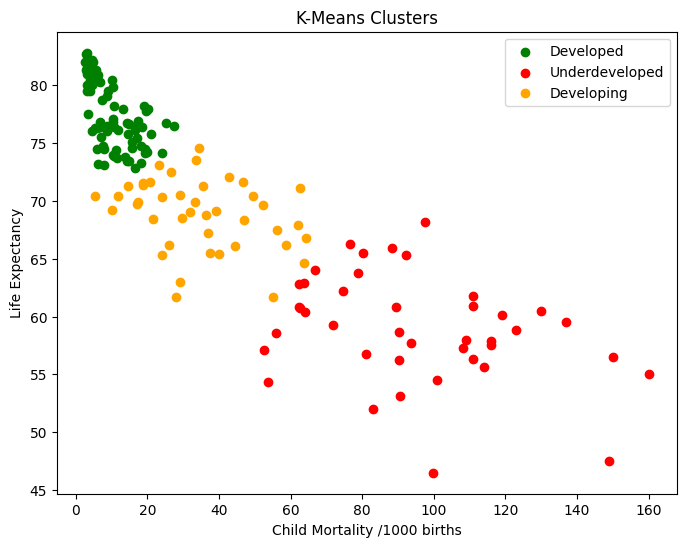

In [8]:
x = (x * std)+mean
plt.figure(figsize=(8,6))

centroid_orig = (final_centroids * std) + mean

order = np.argsort(centroid_orig[:, 0])
cluster_names = {order[0]: 'Developed', order[1]: 'Developing', order[2]: 'Underdeveloped'}

color_map = {'Developed': 'green', 'Developing': 'orange', 'Underdeveloped': 'red'}

for cluster in range(k):
    points = x[labels == cluster]
    plt.scatter(points[:,0], points[:,1], label=cluster_names[cluster], color=color_map[cluster_names[cluster]])

plt.xlabel("Child Mortality /1000 births")
plt.ylabel("Life Expectancy")
plt.title("K-Means Clusters")
plt.legend()
plt.show()